In [2]:
import sys
import numpy as np
import matplotlib.pyplot as plt


sys.path.append('../')


In [3]:
# Get the path
from src_experiment.paths import outputs

def get_path(n_features, n_neurons):
    name = f"{n_features}_features_[{n_neurons}, {n_neurons}, {n_neurons}]"
    return outputs / f"blobs_capacity/{name}/{name}.h5"
get_path(2,3)

PosixPath('/home/johan/Documents/phd/WP1/geometric_binning_estimator/outputs/blobs_capacity/2_features_[3, 3, 3]/2_features_[3, 3, 3].h5')

In [4]:
from src_experiment.estimate_quantities import ExperimentEvaluator
import seaborn as sns
import matplotlib.pyplot as plt
# sns.lineplot(data=df_results, x="epoch", y="I(X;W)", hue="layer_idx")
# plt.show()

In [5]:
ev = ExperimentEvaluator(get_path(10,3))
df_results = ev.evaluate_all()

Loaded 2000 points. Found 17 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Evaluation complete.


In [6]:
H_X = np.log2(ev.N_total)
H_Y = np.log2(len(ev.unique_classes))

In [7]:
df_results

,epoch,layer_idx,I(Y;W),I(X;W)
0,0,1,0.977763,1.503418
1,0,2,0.981600,1.823554
2,0,3,0.981600,2.260355
3,0,4,1.037738,2.935733
4,1,1,1.083545,2.037365
...,...,...,...,...
63,90,4,1.450318,2.185246
64,100,1,1.432380,1.604467
65,100,2,1.433757,1.621997
66,100,3,1.439172,1.982871


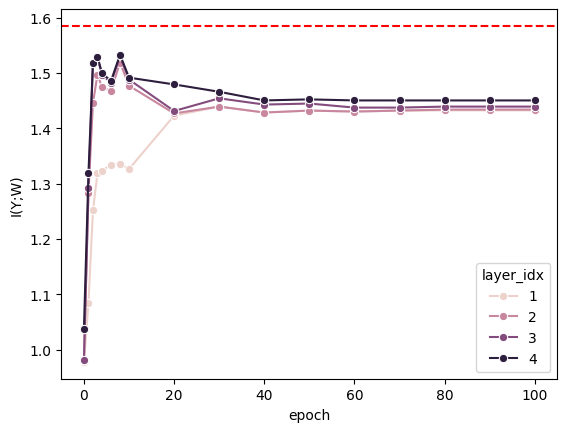

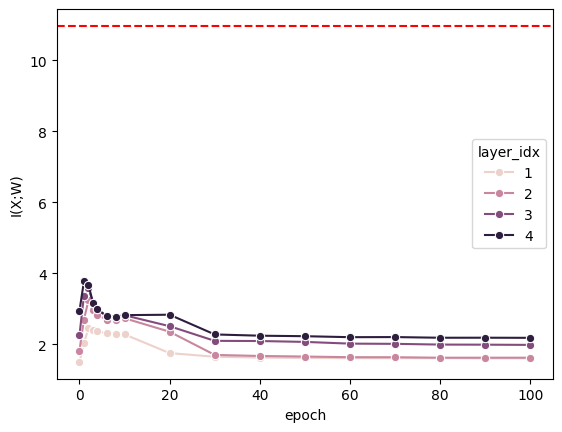

In [8]:
sns.lineplot(data=df_results, x="epoch", y="I(Y;W)", hue="layer_idx", marker="o")
plt.axhline(H_Y, color="red", linestyle="--", label=r"$H(Y)$")
plt.show()

sns.lineplot(data=df_results, x="epoch", y="I(X;W)", hue="layer_idx", marker="o")
plt.axhline(H_X, color="red", linestyle="--", label=r"$H(X)$")
plt.show()  

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def plot_information_plane(df_results, H_X=None, H_Y=None):
    """
    Plots the Information Plane: I(X;W) vs I(Y;W) over epochs.
    Lines connecting epochs are colored distinctly per layer.
    Optionally includes the theoretical maximum bounds H_X and H_Y.
    """
    plt.figure(figsize=(10, 8))
    
    # Get unique layers
    layers = sorted(df_results["layer_idx"].unique())[:-1]
    
    # Create a distinct color palette for the layers
    layer_colors = sns.color_palette("husl", len(layers))

    for i, layer in enumerate(layers):
        layer_data = df_results[df_results["layer_idx"] == layer].sort_values("epoch")
        
        # Plot the trajectory line
        plt.plot(
            layer_data["I(X;W)"], 
            layer_data["I(Y;W)"], 
            linestyle='-', 
            linewidth=2.5,
            alpha=0.8, 
            color=layer_colors[i],
            label=f'Layer {layer}', 
            zorder=2
        )
        
        # Scatter the epoch points
        sc = plt.scatter(
            layer_data["I(X;W)"], 
            layer_data["I(Y;W)"], 
            c=layer_data["epoch"], 
            cmap='viridis', 
            s=60, 
            edgecolor='w',
            zorder=3
        )

    # ---------------------------------------------------------
    # PLOT THE THEORETICAL BOUNDS
    # ---------------------------------------------------------
    if H_X is not None:
        # Vertical line for Maximum Memorization
        plt.axvline(
            x=H_X, color='red', linestyle='--', linewidth=2, alpha=0.8,
            label=f'H(X) Bound (Max Memorization) = {H_X:.2f}', zorder=1
        )
    if H_Y is not None:
        # Horizontal line for Maximum Prediction
        plt.axhline(
            y=H_Y, color='blue', linestyle='--', linewidth=2, alpha=0.8,
            label=f'H(Y) Bound (Max Prediction) = {H_Y:.2f}', zorder=1
        )

    # Add a colorbar for the epochs
    cbar = plt.colorbar(sc)
    cbar.set_label('Epochs (Time)')

    # Labels and Title
    plt.title('The Information Plane: Network Trajectory over Training')
    plt.xlabel('I(X; W) [Bits] $\longrightarrow$ Memorization / Complexity')
    plt.ylabel('I(Y; W) [Bits] $\longrightarrow$ Prediction / Accuracy')
    
    # Adjust axes limits to ensure bounds are nicely framed
    x_min, x_max = plt.xlim()
    y_min, y_max = plt.ylim()
    
    if H_X is not None:
        plt.xlim(0, max(x_max, H_X * 1.05)) # Give 5% padding past the bound
    else:
        pass
        # plt.xlim(left=0)
        
    if H_Y is not None:
        plt.ylim(0, max(y_max, H_Y * 1.05))
    else:
        pass
        # plt.ylim(bottom=0)

    # Grid and Legend
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(title="Network Layers & Bounds", loc='lower right', framealpha=0.9)
    
    plt.tight_layout()
    plt.show()

<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
<>:67: SyntaxWarning: invalid escape sequence '\l'
<>:68: SyntaxWarning: invalid escape sequence '\l'
/tmp/ipykernel_423927/1550430895.py:67: SyntaxWarning: invalid escape sequence '\l'
  plt.xlabel('I(X; W) [Bits] $\longrightarrow$ Memorization / Complexity')
/tmp/ipykernel_423927/1550430895.py:68: SyntaxWarning: invalid escape sequence '\l'
  plt.ylabel('I(Y; W) [Bits] $\longrightarrow$ Prediction / Accuracy')


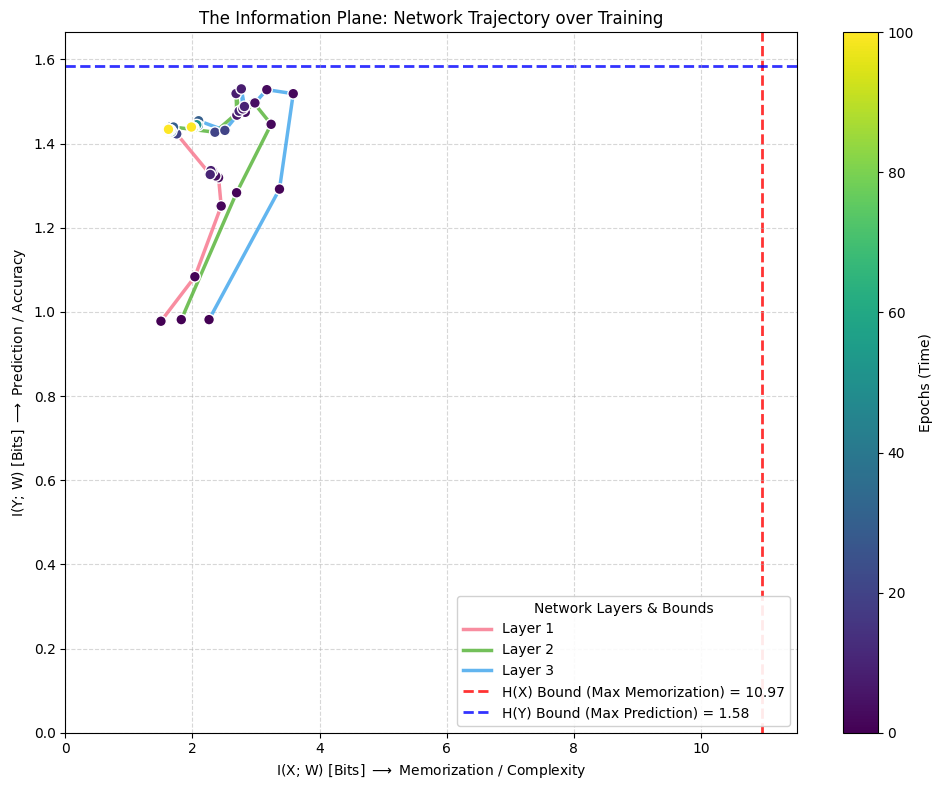

In [10]:
from scipy.stats import entropy

# 1. Calculate H(X) bound (Data Entropy / Max Memorization)
# Since every point is assumed uniform, H(X) = log2(N)
H_X = np.log2(ev.N_total)

# 2. Calculate H(Y) bound (Label Entropy / Max Prediction)
# Find the distribution of your classes
_, counts = np.unique(ev.labels, return_counts=True)
probabilities = counts / counts.sum()
H_Y = entropy(probabilities, base=2)

# 3. Plot!
plot_information_plane(df_results, H_X=H_X, H_Y=H_Y)

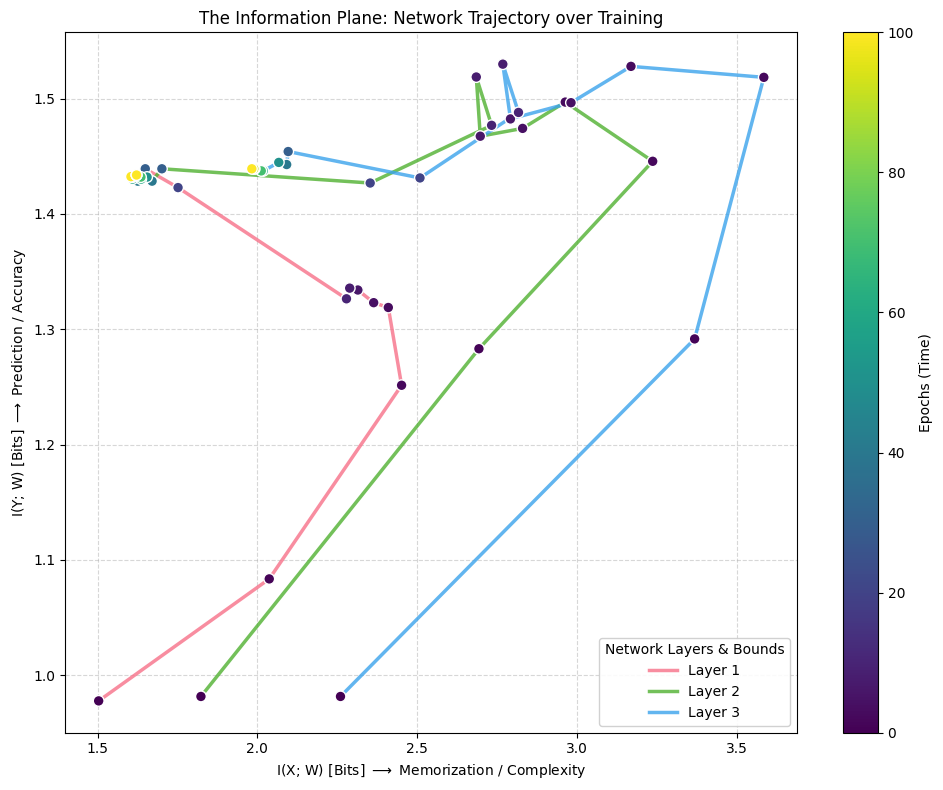

In [11]:
plot_information_plane(df_results)

In [12]:
from visualization.plot_MI_across_layers import plot_layer_MI

In [13]:
# 1. Define your dataset parameters
# n_features_list = [2,3,4,5,10,15]
# neuron_configs = [3, 5, 7, 15, 25]
# for n_features in n_features_list:
#     # 2. Gather the results into a dictionary
#     results_dict = {}

#     for n_neurons in neuron_configs:
#         # Assuming get_path() is your helper function that returns the .h5 filepath
#         h5_filepath = get_path(n_features, n_neurons) 
        
#         evaluator = ExperimentEvaluator(h5_filepath)
#         df_results = evaluator.evaluate_all()
        
#         # Store the resulting DataFrame in the dictionary
#         results_dict[n_neurons] = df_results

#     # 3. Calculate your theoretical bound (optional but recommended!)
#     # You can just pull the N_total from the very last evaluator run
#     # H_X_bound = np.log2(evaluator.N_total)

#     # 4. Generate the plot for Memorization Capacity I(X;W)
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(X;W)",
#         title_suffix=f"for Blobs dataset (n_features={n_features})",
#         # save_path=f"blobs_capacity_{n_features}_features_IXW.png",
#         H_bound=H_X
#     )

#     # 5. You can also easily generate the plot for Predictive Capacity I(Y;W)!
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(Y;W)",
#         title_suffix=f"for Blobs dataset (n_features={n_features})",
#         # save_path=f"blobs_capacity_{n_features}_features_IYW.png",
#         H_bound=H_Y
#     )

In [14]:
def get_wbc_path(n_dim, n_neurons):
    name = f"{n_dim}_dim_[{n_neurons}, {n_neurons}, {n_neurons}]"
    return outputs / f"wbc_capacity/{name}/{name}.h5"

# # 1. Define your dataset parameters
# n_dims = [2,3,4,5,10,15]
# neuron_configs = [3, 5, 7, 15, 25, 50]
# for n_dim in n_dims:
#     # 2. Gather the results into a dictionary
#     results_dict = {}

#     for n_neurons in neuron_configs:
#         # Assuming get_path() is your helper function that returns the .h5 filepath
#         h5_filepath = get_wbc_path(n_dim, n_neurons) 
        
#         evaluator = ExperimentEvaluator(h5_filepath)
#         df_results = evaluator.evaluate_all()
        
#         # Store the resulting DataFrame in the dictionary
#         results_dict[n_neurons] = df_results

#     # 3. Calculate your theoretical bound (optional but recommended!)
#     # You can just pull the N_total from the very last evaluator run
#     # H_X_bound = np.log2(evaluator.N_total)
#     # 1. Calculate H(X) bound (Data Entropy / Max Memorization)
#     # Since every point is assumed uniform, H(X) = log2(N)
#     H_X = np.log2(evaluator.N_total)

#     # 2. Calculate H(Y) bound (Label Entropy / Max Prediction)
#     # Find the distribution of your classes
#     _, counts = np.unique(evaluator.labels, return_counts=True)
#     probabilities = counts / counts.sum()
#     H_Y = entropy(probabilities, base=2)

#     # 4. Generate the plot for Memorization Capacity I(X;W)
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(X;W)",
#         title_suffix=f"for WBC dataset (n_dim={n_dim})",
#         # save_path=f"wbc_capacity_{n_dim}_dim_IXW.png",
#         H_bound=H_X
#     )

#     # 5. You can also easily generate the plot for Predictive Capacity I(Y;W)!
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(Y;W)",
#         title_suffix=f"for WBC dataset (n_dim={n_dim})",
#         # save_path=f"wbc_capacity_{n_dim}_dim_IYW.png",
#         H_bound=H_Y
#     )

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

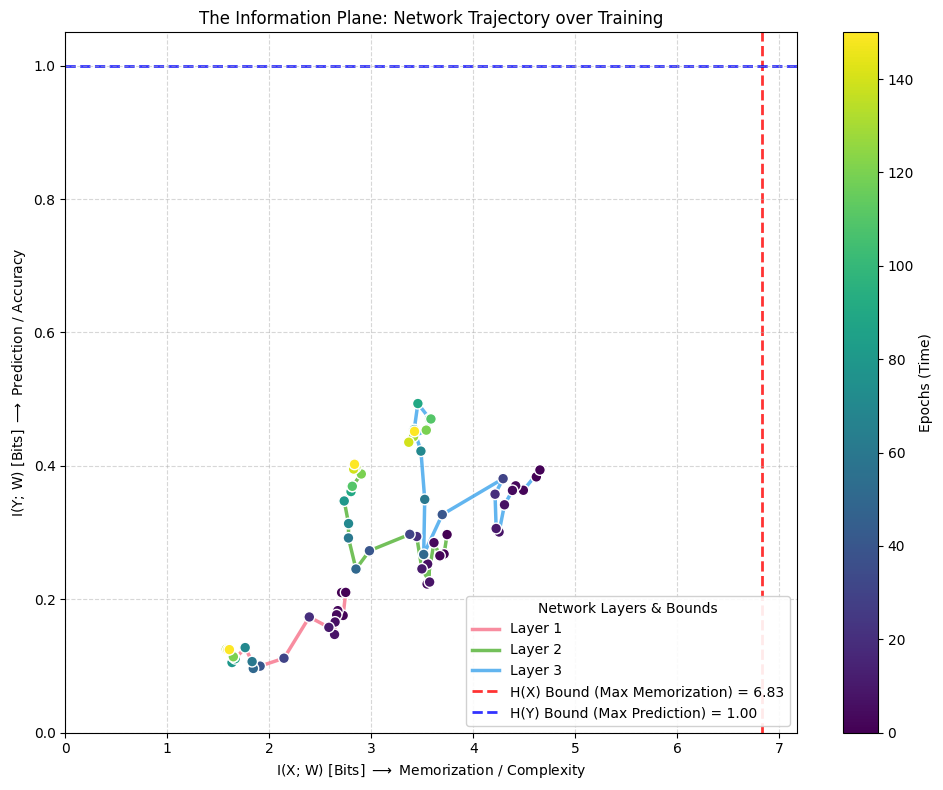

In [15]:
ev = ExperimentEvaluator(get_wbc_path(n_dim=15, n_neurons=5))
df_results = ev.evaluate_all()
H_X = np.log2(ev.N_total)
H_Y = np.log2(len(ev.unique_classes))
plot_information_plane(df_results, H_X, H_Y)

In [16]:
df_results

,epoch,layer_idx,I(Y;W),I(X;W)
0,0,1,0.210158,2.709199
1,0,2,0.297075,3.743258
2,0,3,0.383570,4.618222
3,0,4,0.383570,4.618222
4,1,1,0.210378,2.749363
...,...,...,...,...
83,140,4,0.619110,3.988568
84,150,1,0.124557,1.609129
85,150,2,0.402396,2.835692
86,150,3,0.451750,3.424102


In [17]:
import pandas as pd
def get_wbc_path_seed(n_dim, n_neurons, seed):
    return outputs / f"wbc_capacity/{n_dim}_dim_[{n_neurons}, {n_neurons}, {n_neurons}]/seed_{seed}.h5"

def get_mean_MI(n_dim, n_neurons, seeds=[101,102,103,104,105]):
    # Should return the Mi for all epochs for all paths, and the average across all paths
    MIs = {}
    for seed in seeds:
        path = get_wbc_path_seed(n_dim, n_neurons, seed)
        ev = ExperimentEvaluator(path)
        df_results = ev.evaluate_all()
        MIs["epoch"] = df_results["epoch"].values if "epoch" not in MIs else MIs["epoch"]
        MIs["layer_idx"] = df_results["layer_idx"].values if "layer_idx" not in MIs else MIs["layer_idx"]
        MIs[f"I(Y;W)_seed_{seed}"] = df_results["I(Y;W)"].values
        MIs[f"I(X;W)_seed_{seed}"] = df_results["I(X;W)"].values
    # Now calculate the mean across seeds for each epoch and layer
    MI_mean = {}
    MIs["I(Y;W)_mean"] = np.mean([MIs[f"I(Y;W)_seed_{seed}"] for seed in seeds], axis=0)
    MIs["I(X;W)_mean"] = np.mean([MIs[f"I(X;W)_seed_{seed}"] for seed in seeds], axis=0)
    MI_mean["epoch"] = MIs["epoch"]
    MI_mean["layer_idx"] = MIs["layer_idx"]
    MI_mean["I(Y;W)"] = MIs["I(Y;W)_mean"]
    MI_mean["I(X;W)"] = MIs["I(X;W)_mean"]
    return pd.DataFrame(MIs), pd.DataFrame(MI_mean)
        
            
seeds = [101,102,103,104,105]
# test_paths = [get_wbc_path_seed(10, 3, seed) for seed in seeds]

fulldf, mean_df = get_mean_MI(10, 3, seeds)

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

In [18]:
df_results

,epoch,layer_idx,I(Y;W),I(X;W)
0,0,1,0.210158,2.709199
1,0,2,0.297075,3.743258
2,0,3,0.383570,4.618222
3,0,4,0.383570,4.618222
4,1,1,0.210378,2.749363
...,...,...,...,...
83,140,4,0.619110,3.988568
84,150,1,0.124557,1.609129
85,150,2,0.402396,2.835692
86,150,3,0.451750,3.424102


In [19]:
mean_df

,epoch,layer_idx,I(Y;W),I(X;W)
0,0,1,0.071921,1.312627
1,0,2,0.119958,1.894782
2,0,3,0.124357,1.955598
3,0,4,0.134705,2.015646
4,1,1,0.073803,1.301889
...,...,...,...,...
83,140,4,0.481475,2.290832
84,150,1,0.145860,1.076348
85,150,2,0.293307,1.710710
86,150,3,0.338169,1.896623


In [ ]:
# 1. Define your dataset parameters
# n_dims = [2,3,4,5,10,15]
# neuron_configs = [3, 5, 7, 15, 25, 50]
# seeds = [101,102,103,104,105]

# # Find bounds
# ev = ExperimentEvaluator(get_wbc_path_seed(n_dim=2, n_neurons=3, seed=101))
# ev.evaluate_all()
# H_X = np.log2(ev.N_total)
# _, counts = np.unique(ev.labels, return_counts=True)
# probabilities = counts / counts.sum()
# H_Y = entropy(probabilities, base=2)

# for n_dim in n_dims:
#     # 2. Gather the results into a dictionary
#     results_dict = {}

#     for n_neurons in neuron_configs:
#         full, mean_df = get_mean_MI(n_dim, n_neurons, seeds)
#         results_dict[n_neurons] = mean_df

#     # 3. Calculate your theoretical bound (optional but recommended!)
#     # # You can just pull the N_total from the very last evaluator run
#     # # H_X_bound = np.log2(evaluator.N_total)
#     # # 1. Calculate H(X) bound (Data Entropy / Max Memorization)
#     # # Since every point is assumed uniform, H(X) = log2(N)
#     # H_X = np.log2(evaluator.N_total)

#     # # 2. Calculate H(Y) bound (Label Entropy / Max Prediction)
#     # # Find the distribution of your classes
#     # _, counts = np.unique(evaluator.labels, return_counts=True)
#     # probabilities = counts / counts.sum()
#     # H_Y = entropy(probabilities, base=2)

#     # 4. Generate the plot for Memorization Capacity I(X;W)
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(X;W)",
#         title_suffix=f"for WBC dataset (n_dim={n_dim})",
#         # save_path=f"wbc_capacity_{n_dim}_dim_IXW.png",
#         H_bound=H_X
#     )

#     # 5. You can also easily generate the plot for Predictive Capacity I(Y;W)!
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(Y;W)",
#         title_suffix=f"for WBC dataset (n_dim={n_dim})",
#         # save_path=f"wbc_capacity_{n_dim}_dim_IYW.png",
#         H_bound=H_Y
#     )

Loaded 114 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - Lo

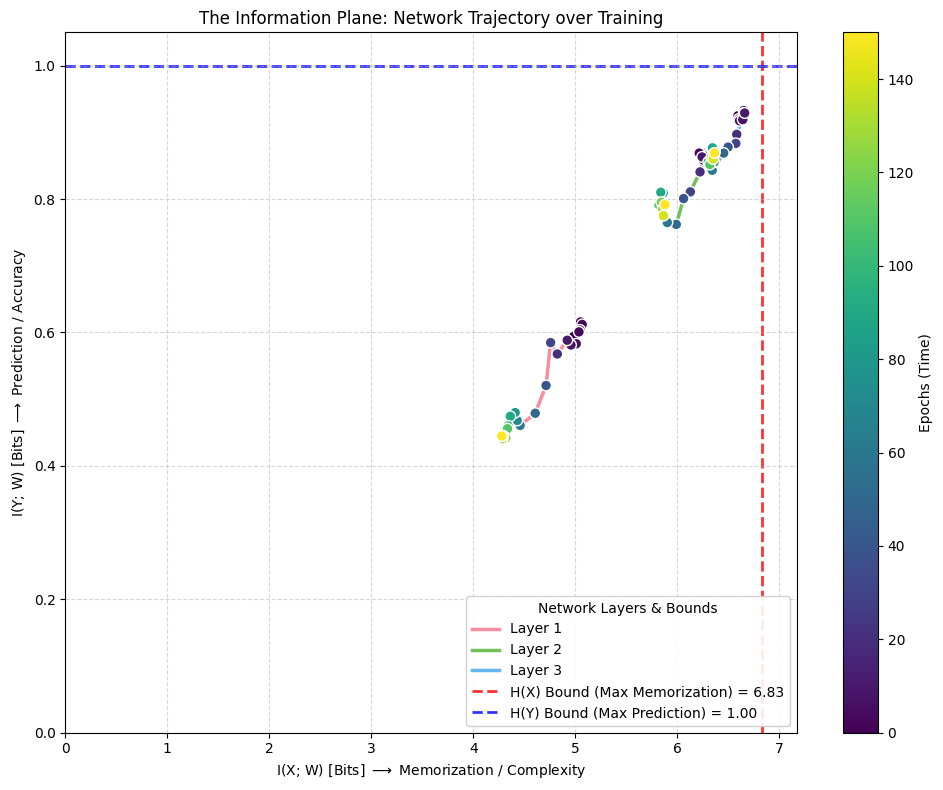

In [21]:
# seeds = [101,102,103,104,105]
full, mean_df = get_mean_MI(n_dim=10, n_neurons=15, seeds=seeds)
plot_information_plane(mean_df, H_X, H_Y)

## MNIST


In [22]:
def get_mnist_path_seed(n_dim, n_neurons, seed):
    return outputs / f"mnist_capacity/{n_dim}_dim_[{n_neurons}, {n_neurons}, {n_neurons}]/seed_{seed}.h5"

def get_mean_MI_mnist(n_dim, n_neurons, seeds=[101,102]):
    # Should return the Mi for all epochs for all paths, and the average across all paths
    MIs = {}
    for seed in seeds:
        path = get_mnist_path_seed(n_dim, n_neurons, seed)
        ev = ExperimentEvaluator(path)
        df_results = ev.evaluate_all()
        MIs["epoch"] = df_results["epoch"].values if "epoch" not in MIs else MIs["epoch"]
        MIs["layer_idx"] = df_results["layer_idx"].values if "layer_idx" not in MIs else MIs["layer_idx"]
        MIs[f"I(Y;W)_seed_{seed}"] = df_results["I(Y;W)"].values
        MIs[f"I(X;W)_seed_{seed}"] = df_results["I(X;W)"].values
    # Now calculate the mean across seeds for each epoch and layer
    MI_mean = {}
    MIs["I(Y;W)_mean"] = np.mean([MIs[f"I(Y;W)_seed_{seed}"] for seed in seeds], axis=0)
    MIs["I(X;W)_mean"] = np.mean([MIs[f"I(X;W)_seed_{seed}"] for seed in seeds], axis=0)
    MI_mean["epoch"] = MIs["epoch"]
    MI_mean["layer_idx"] = MIs["layer_idx"]
    MI_mean["I(Y;W)"] = MIs["I(Y;W)_mean"]
    MI_mean["I(X;W)"] = MIs["I(X;W)_mean"]
    return pd.DataFrame(MIs), pd.DataFrame(MI_mean)

Loaded 10000 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - 

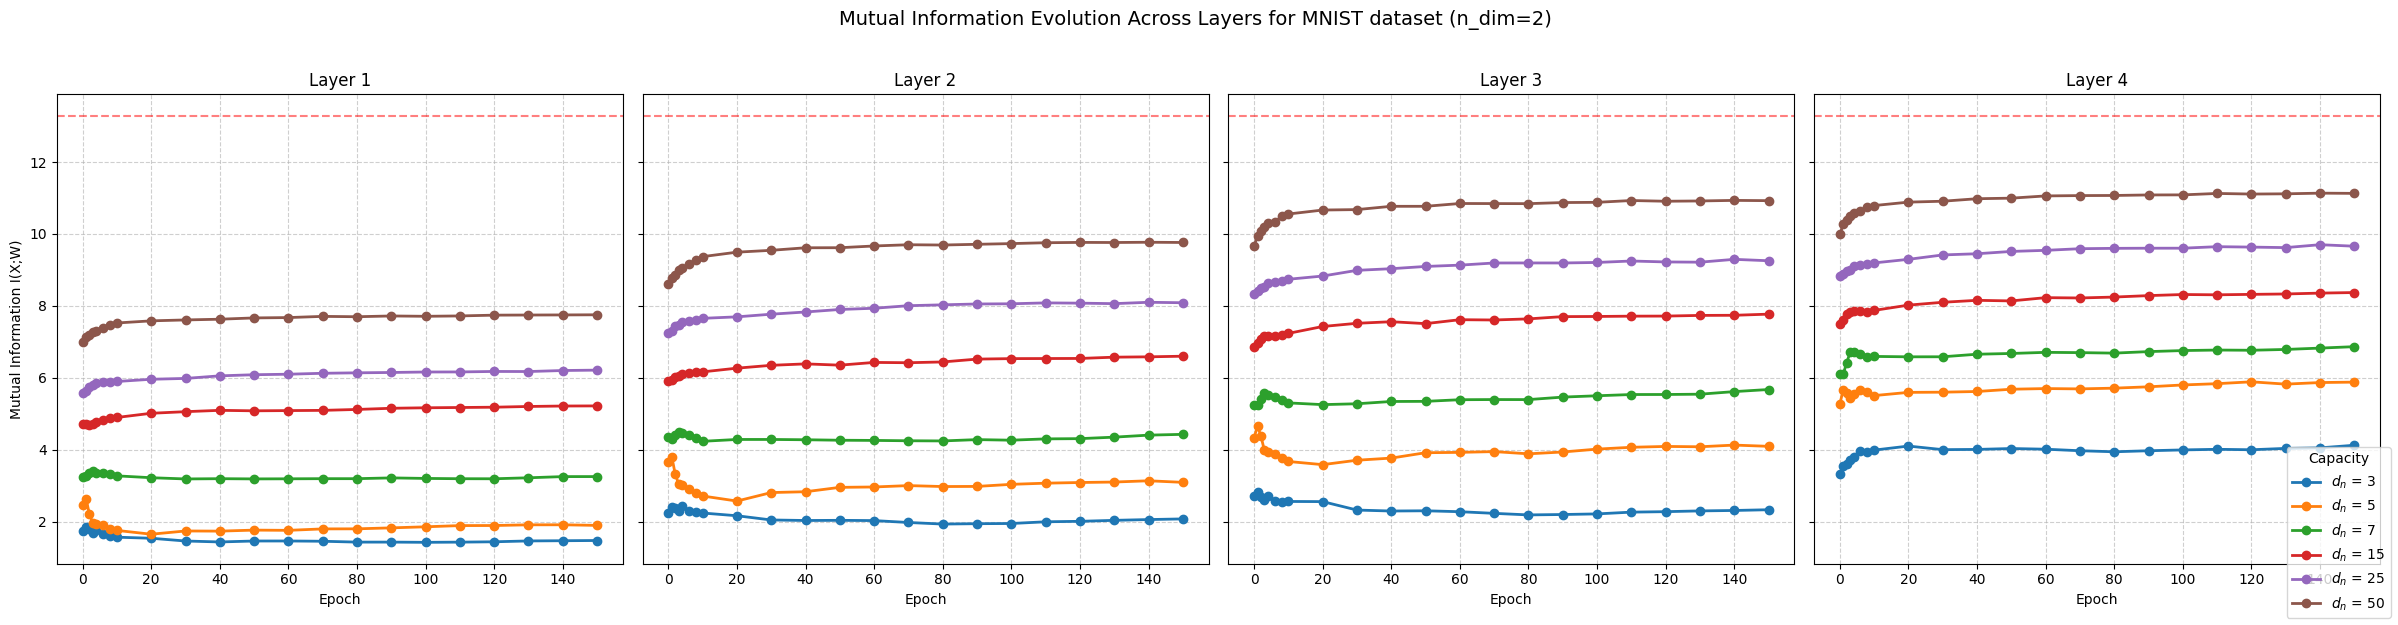

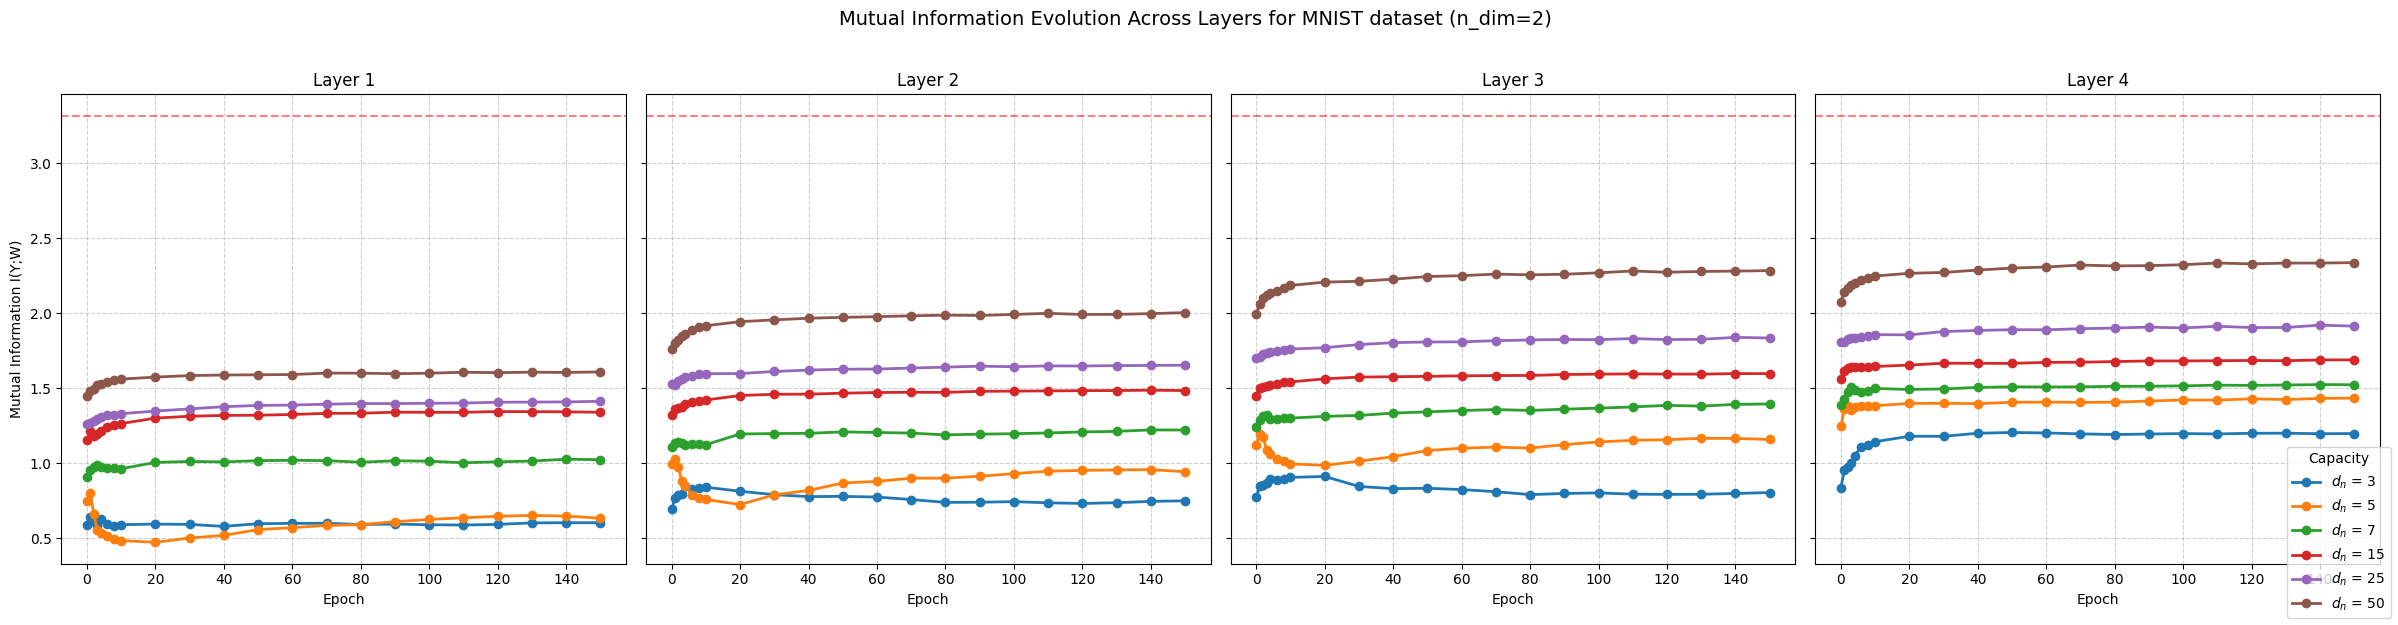

Loaded 10000 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - 

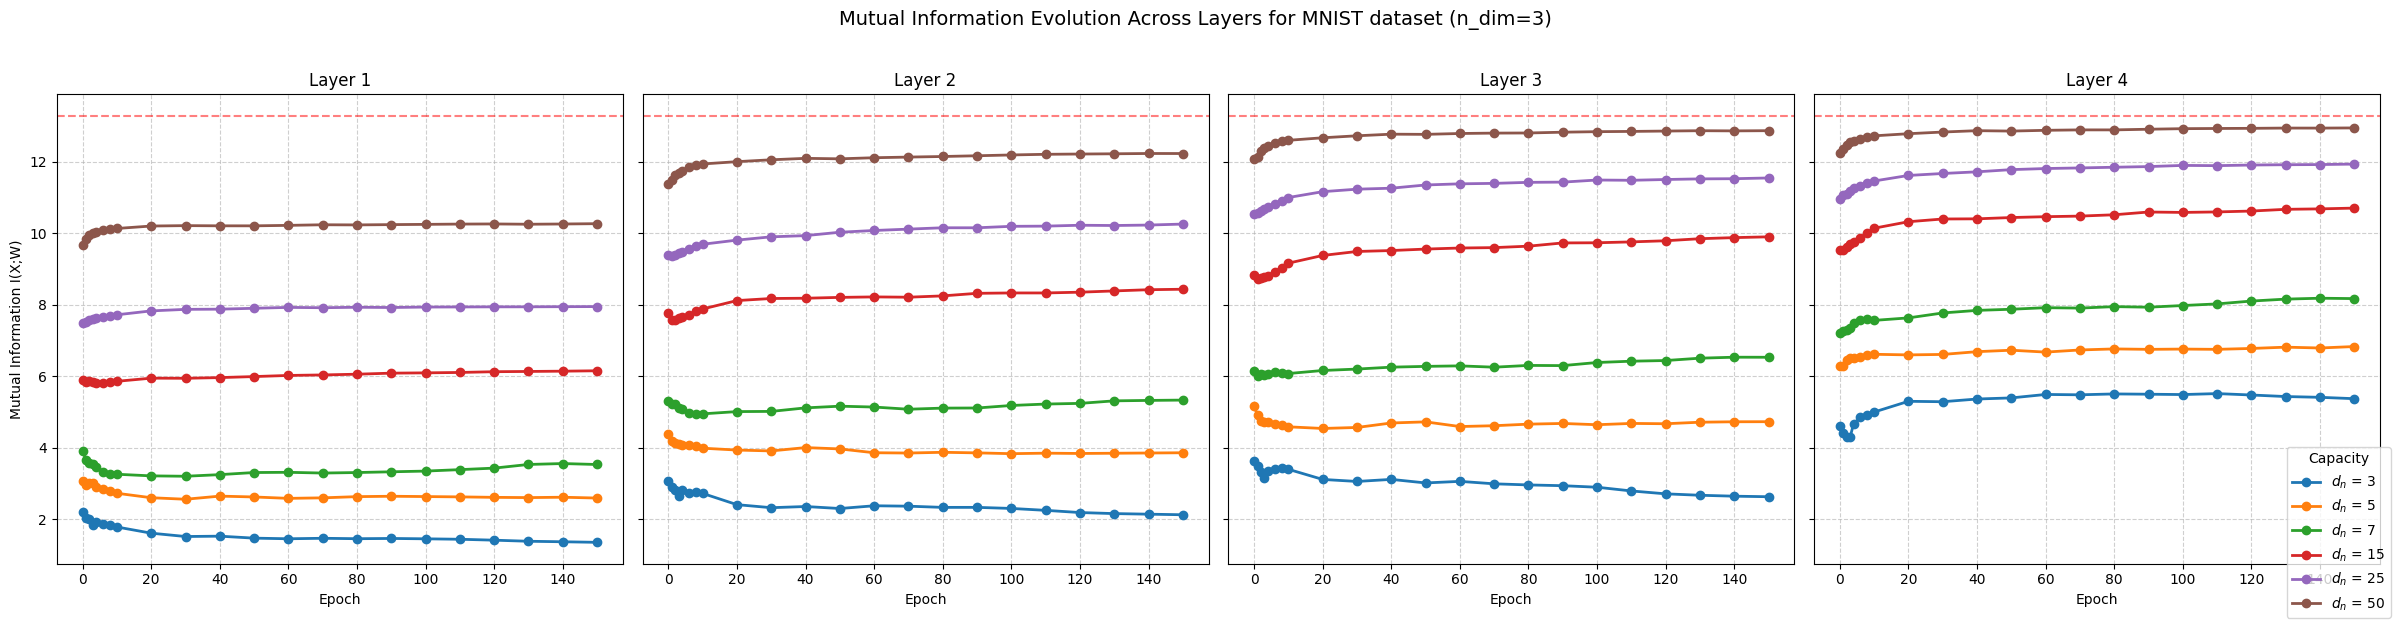

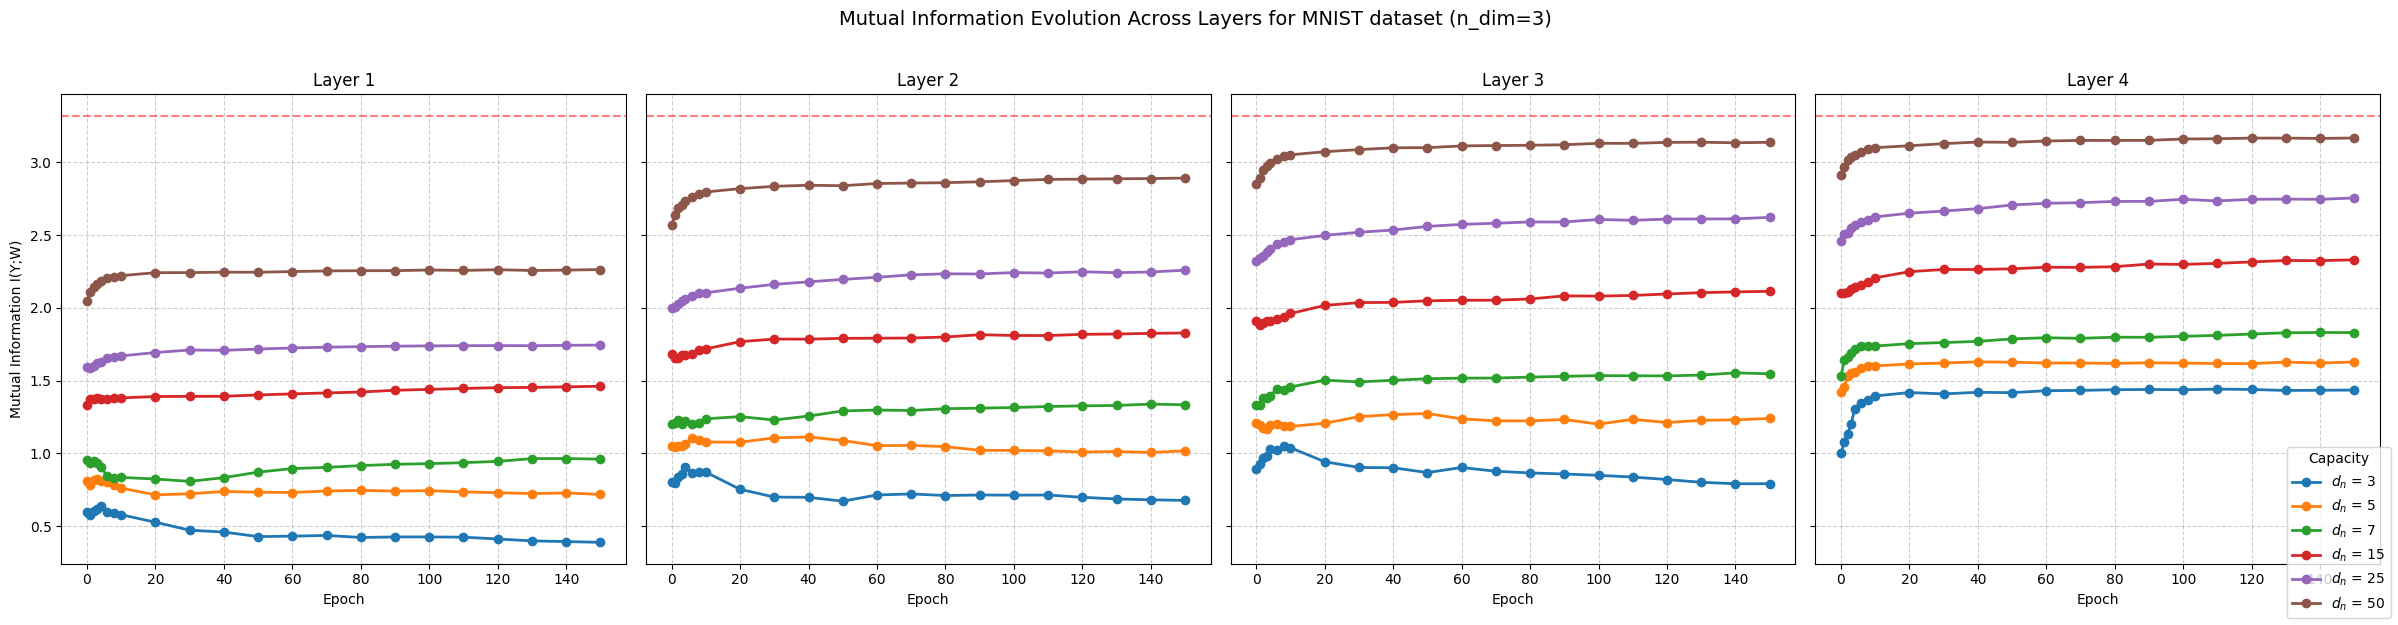

Loaded 10000 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - 

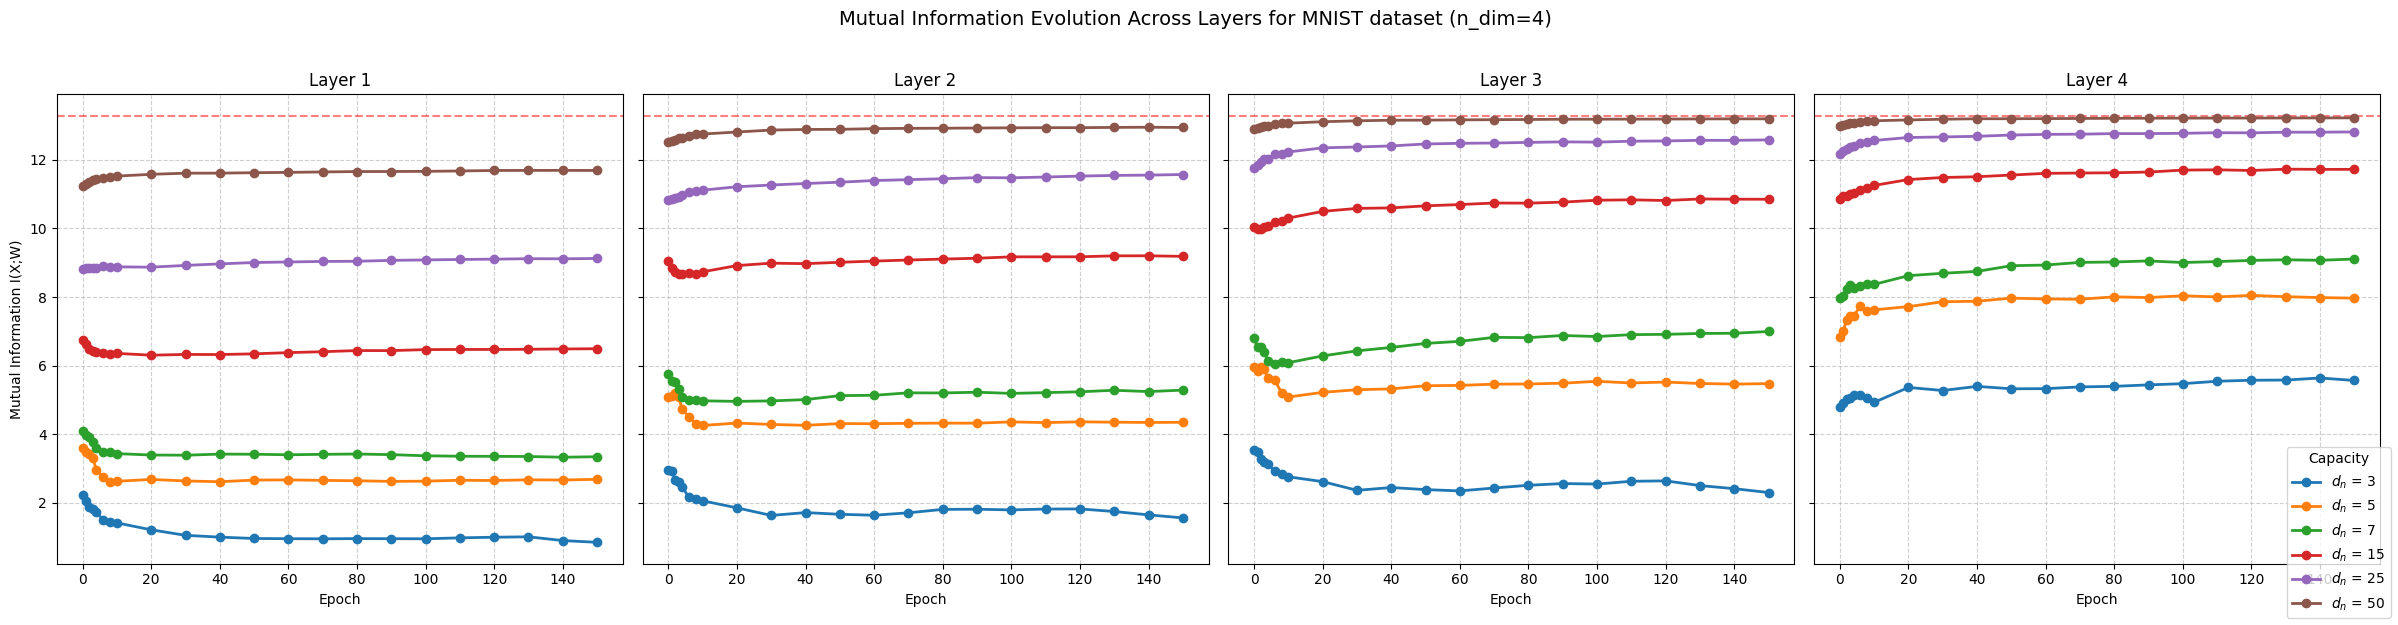

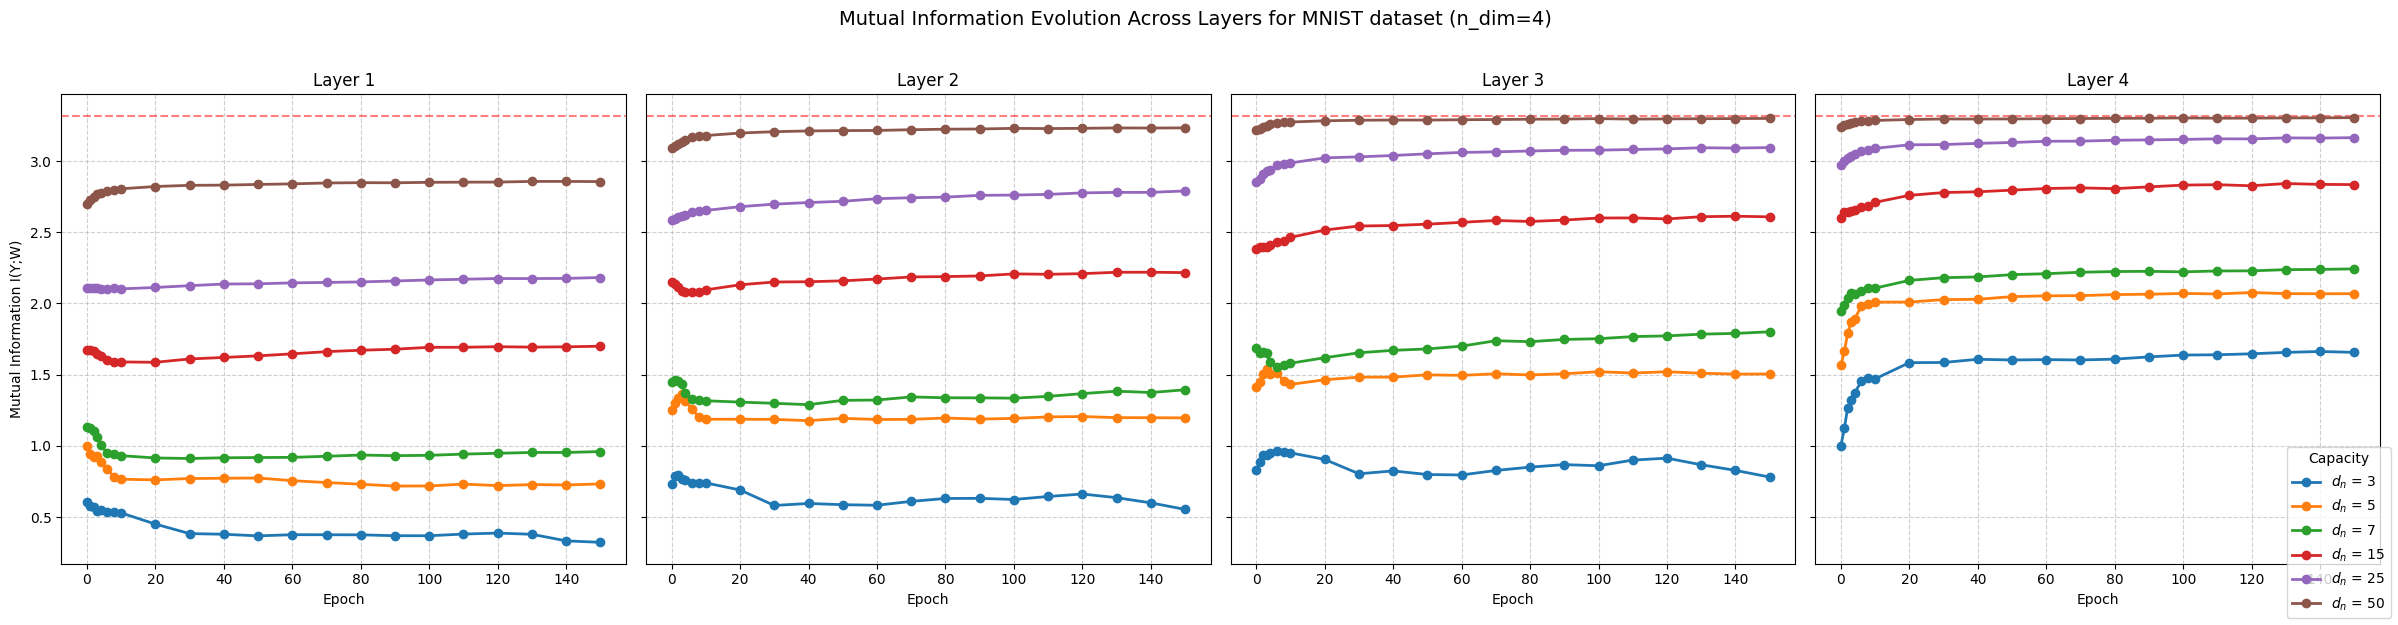

Loaded 10000 points. Found 22 epochs.
Processing epoch 0...
  - Loading Epoch 0...
Processing epoch 1...
  - Loading Epoch 1...
Processing epoch 2...
  - Loading Epoch 2...
Processing epoch 3...
  - Loading Epoch 3...
Processing epoch 4...
  - Loading Epoch 4...
Processing epoch 6...
  - Loading Epoch 6...
Processing epoch 8...
  - Loading Epoch 8...
Processing epoch 10...
  - Loading Epoch 10...
Processing epoch 20...
  - Loading Epoch 20...
Processing epoch 30...
  - Loading Epoch 30...
Processing epoch 40...
  - Loading Epoch 40...
Processing epoch 50...
  - Loading Epoch 50...
Processing epoch 60...
  - Loading Epoch 60...
Processing epoch 70...
  - Loading Epoch 70...
Processing epoch 80...
  - Loading Epoch 80...
Processing epoch 90...
  - Loading Epoch 90...
Processing epoch 100...
  - Loading Epoch 100...
Processing epoch 110...
  - Loading Epoch 110...
Processing epoch 120...
  - Loading Epoch 120...
Processing epoch 130...
  - Loading Epoch 130...
Processing epoch 140...
  - 

KeyboardInterrupt: 

In [ ]:
# # 1. Define your dataset parameters
# n_dims = [2,3,4,5,10,15]
# neuron_configs = [3, 5, 7, 15, 25, 50]
# seeds = [101,102, 103,104,105]

# # Find bounds
# ev = ExperimentEvaluator(get_mnist_path_seed(n_dim=2, n_neurons=3, seed=101))
# ev.evaluate_all()
# H_X = np.log2(ev.N_total)
# _, counts = np.unique(ev.labels, return_counts=True)
# probabilities = counts / counts.sum()
# H_Y = entropy(probabilities, base=2)

# for n_dim in n_dims:
#     # 2. Gather the results into a dictionary
#     results_dict = {}

#     for n_neurons in neuron_configs:
#         full, mean_df = get_mean_MI_mnist(n_dim, n_neurons, seeds)
#         results_dict[n_neurons] = mean_df

#     # 3. Calculate your theoretical bound (optional but recommended!)
#     # # You can just pull the N_total from the very last evaluator run
#     # # H_X_bound = np.log2(evaluator.N_total)
#     # # 1. Calculate H(X) bound (Data Entropy / Max Memorization)
#     # # Since every point is assumed uniform, H(X) = log2(N)
#     # H_X = np.log2(evaluator.N_total)

#     # # 2. Calculate H(Y) bound (Label Entropy / Max Prediction)
#     # # Find the distribution of your classes
#     # _, counts = np.unique(evaluator.labels, return_counts=True)
#     # probabilities = counts / counts.sum()
#     # H_Y = entropy(probabilities, base=2)

#     # 4. Generate the plot for Memorization Capacity I(X;W)
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(X;W)",
#         title_suffix=f"for MNIST dataset (n_dim={n_dim})",
#         # save_path=f"mnist_capacity_{n_dim}_dim_IXW.png",
#         H_bound=H_X
#     )

#     # 5. You can also easily generate the plot for Predictive Capacity I(Y;W)!
#     plot_layer_MI(
#         results_dict=results_dict,
#         mi_type="I(Y;W)",
#         title_suffix=f"for MNIST dataset (n_dim={n_dim})",
#         # save_path=f"mnist_capacity_{n_dim}_dim_IYW.png",
#         H_bound=H_Y
#     )